In [1]:
import numpy as np

import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import struct
import jax.numpy as jnp
import jax
import seaborn
import scienceplots

plt.style.use(['science','notebook'])


jax.config.update("jax_enable_x64", True)

In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
pi = jnp.pi
N = 2**9

L = 2*pi
dx = L/N

nu = 1e-3
kvals = np.arange(0,N//2)

# ----------------------------------------
# Spectral Grid Setup (Memory-Efficient)
# ----------------------------------------

kx , ky , kz  = np.meshgrid(jnp.fft.fftfreq(N, dx)*(2*pi),jnp.fft.fftfreq(N, dx)*(2*pi), jnp.fft.rfftfreq(N, dx)*(2*pi),indexing= 'ij')

k_vec = np.stack([kx,ky,kz])

k_sq = (k_vec[0]**2 + k_vec[1]**2 + k_vec[2]**2)

k = np.sqrt(k_sq)

derivative_operator = 1j*k_vec

shells = np.arange(-0.5, N//2 + 1 , 1.)
shells[0] = 0.
# ----------------------------------------
# Dealiasing and Projection Utilities
# ----------------------------------------

alias_mask = (abs(k_vec[0])<=N//3)*(abs(k_vec[1])<=N//3)*(abs(k_vec[2])<=N//3)

k_over_k_sq = np.where(k_sq == 0 , 0 ,  k_vec/k_sq)*alias_mask

kint = np.clip(np.round(k,0).astype(int),None,N//2)

/var/folders/br/q1r8zd1d6z50qx6y9z0kdpk00000gn/T/ipykernel_3038/3393664484.py:32: RuntimeWarning: invalid value encountered in divide
  k_over_k_sq = np.where(k_sq == 0 , 0 ,  k_vec/k_sq)*alias_mask


In [4]:
# HOMOGENEOUS

avg_dissp = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p0.npz')['avg_dissp']])

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p03.npz')['avg_dissp']],axis =0)
 
avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p05.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p07.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p1.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p3.npz')['avg_dissp']],axis =0)

avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Homo_P0p5.npz')['avg_dissp']],axis =0)


# Fractal

# avg_dissp = np.array([np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D3p0.npz')['avg_dissp']])

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p98.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p95.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p90.npz')['avg_dissp']],axis =0)

# avg_dissp  = np.append(avg_dissp , [np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Energy_spectra/Energy_Fluz_Decimated_Fractal_D2p80.npz')['avg_dissp']],axis =0)

In [6]:
kvals = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p5/spectra1.out')[1:N//3,0]

spec_P0p5 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p5/spectra1.out')[1:N//3,1]

spec_P0p5  = np.vstack((spec_P0p5 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p5/spectra2.out')[1:N//3,1]))

spec_P0p5  = np.vstack((spec_P0p5 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p5/spectra3.out')[1:N//3,1]))
 
spec_P0p5  = np.vstack((spec_P0p5 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p5/spectra4.out')[1:N//3,1]))

spec_P0p5  = np.vstack((spec_P0p5 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p5/spectra5.out')[1:N//3,1]))




spec_P0p3 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p3/spectra1.out')[1:N//3,1]

spec_P0p3  = np.vstack((spec_P0p3 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p3/spectra2.out')[1:N//3,1]))

spec_P0p3  = np.vstack((spec_P0p3 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p3/spectra3.out')[1:N//3,1]))
 
spec_P0p3  = np.vstack((spec_P0p3 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p3/spectra4.out')[1:N//3,1]))

spec_P0p3  = np.vstack((spec_P0p3 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p3/spectra5.out')[1:N//3,1]))




spec_P0p1 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p1/spectra1.out')[1:N//3,1]

spec_P0p1  = np.vstack((spec_P0p1 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p1/spectra2.out')[1:N//3,1]))

spec_P0p1  = np.vstack((spec_P0p1 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p1/spectra3.out')[1:N//3,1]))
 
spec_P0p1  = np.vstack((spec_P0p1 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p1/spectra4.out')[1:N//3,1]))

spec_P0p1  = np.vstack((spec_P0p1 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p1/spectra5.out')[1:N//3,1]))




spec_P0p07 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p07/spectra1.out')[1:N//3,1]

spec_P0p07  = np.vstack((spec_P0p07 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p07/spectra2.out')[1:N//3,1]))

spec_P0p07  = np.vstack((spec_P0p07 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p07/spectra3.out')[1:N//3,1]))
 
spec_P0p07  = np.vstack((spec_P0p07 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p07/spectra4.out')[1:N//3,1]))

spec_P0p07  = np.vstack((spec_P0p07 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p07/spectra5.out')[1:N//3,1]))


spec_P0p05 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p05/spectra1.out')[1:N//3,1]

spec_P0p05  = np.vstack((spec_P0p05 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p05/spectra2.out')[1:N//3,1]))

spec_P0p05  = np.vstack((spec_P0p05 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p05/spectra3.out')[1:N//3,1]))
 
spec_P0p05  = np.vstack((spec_P0p05 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p05/spectra4.out')[1:N//3,1]))

spec_P0p05  = np.vstack((spec_P0p05 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p05/spectra5.out')[1:N//3,1]))


spec_P0p03 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p03/spectra1.out')[1:N//3,1]

spec_P0p03  = np.vstack((spec_P0p03 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p03/spectra2.out')[1:N//3,1]))

spec_P0p03  = np.vstack((spec_P0p03 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p03/spectra3.out')[1:N//3,1]))
 
spec_P0p03  = np.vstack((spec_P0p03 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p03/spectra4.out')[1:N//3,1]))

spec_P0p03  = np.vstack((spec_P0p03 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_Decimated/spectra_P0p03/spectra5.out')[1:N//3,1]))


In [7]:
kvals = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D3p0/spectra1.out')[1:N//3,0]

spec_D3p0 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D3p0/spectra1.out')[1:N//3,1]

spec_D3p0  = np.vstack((spec_D3p0 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D3p0/spectra2.out')[1:N//3,1]))

spec_D3p0  = np.vstack((spec_D3p0 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D3p0/spectra3.out')[1:N//3,1]))
 
spec_D3p0  = np.vstack((spec_D3p0 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D3p0/spectra4.out')[1:N//3,1]))

spec_D3p0  = np.vstack((spec_D3p0 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D3p0/spectra5.out')[1:N//3,1]))




spec_D2p98 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p98/spectra1.out')[1:N//3,1]

spec_D2p98  = np.vstack((spec_D2p98 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p98/spectra2.out')[1:N//3,1]))

spec_D2p98  = np.vstack((spec_D2p98 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p98/spectra3.out')[1:N//3,1]))
 
spec_D2p98  = np.vstack((spec_D2p98 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p98/spectra4.out')[1:N//3,1]))

spec_D2p98  = np.vstack((spec_D2p98 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p98/spectra5.out')[1:N//3,1]))




spec_D2p95 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p95/spectra1.out')[1:N//3,1]

spec_D2p95  = np.vstack((spec_D2p95 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p95/spectra2.out')[1:N//3,1]))

spec_D2p95  = np.vstack((spec_D2p95 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p95/spectra3.out')[1:N//3,1]))
 
spec_D2p95  = np.vstack((spec_D2p95 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p95/spectra4.out')[1:N//3,1]))

spec_D2p95  = np.vstack((spec_D2p95 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p95/spectra5.out')[1:N//3,1]))




spec_D2p90 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p90/spectra1.out')[1:N//3,1]

spec_D2p90  = np.vstack((spec_D2p90 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p90/spectra2.out')[1:N//3,1]))

spec_D2p90  = np.vstack((spec_D2p90 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p90/spectra3.out')[1:N//3,1]))
 
spec_D2p90  = np.vstack((spec_D2p90 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p90/spectra4.out')[1:N//3,1]))

spec_D2p90  = np.vstack((spec_D2p90 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p90/spectra5.out')[1:N//3,1]))



spec_D2p80 = np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p80/spectra1.out')[1:N//3,1]

spec_D2p80  = np.vstack((spec_D2p80 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p80/spectra2.out')[1:N//3,1]))

spec_D2p80  = np.vstack((spec_D2p80 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p80/spectra3.out')[1:N//3,1]))
 
spec_D2p80  = np.vstack((spec_D2p80 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p80/spectra4.out')[1:N//3,1]))

spec_D2p80  = np.vstack((spec_D2p80 , np.loadtxt('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Spectra_fractal/spectra_D2p80/spectra5.out')[1:N//3,1]))



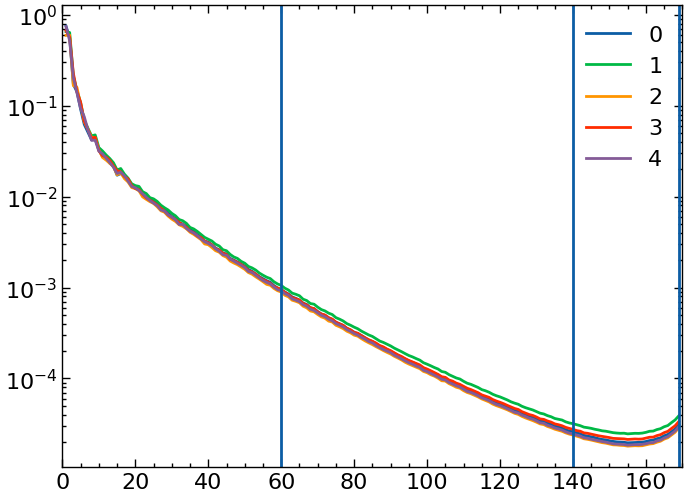

In [6]:
for i in range(5):
    plt.semilogy(kvals, spec_D3p0[i,:], label = i)
plt.xlim(0,N//3)
plt.axvline(N//3-1)
plt.axvline(60)
plt.axvline(140)

plt.legend()

In [9]:
def bootstrap_local_slope(local_slope, nboot=1000):
    """
    Bootstrap mean exponent from local slopes.
    """
    n = len(local_slope)
    alpha = np.empty(nboot)

    for b in range(nboot):
        idx = np.random.randint(0, n, n)
        alpha[b] = local_slope[idx].mean()

    return alpha.mean(), alpha.var(), alpha


# Calculate The $K_{max} \delta$

In [53]:
delta_mean = np.zeros(6)
delta_st_dev = np.zeros(6)
local_slope = jnp.array([0])
    
for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_P0p03[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[0] = mean
delta_st_dev[0] = error
local_slope = jnp.array([0])


for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_P0p05[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[1] = mean
delta_st_dev[1] = error
local_slope = jnp.array([0])


for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_P0p07[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[2] = mean
delta_st_dev[2] = error
local_slope = jnp.array([0])




for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_P0p1[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[3] = mean
delta_st_dev[3] = error
local_slope = jnp.array([0])



for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_P0p3[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[4] = mean
delta_st_dev[4] = error
local_slope = jnp.array([0])



for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_P0p5[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[5] = mean
delta_st_dev[5] = error
local_slope = jnp.array([0])

In [54]:
np.savez("Energy_spectra/delta_vs_homogeneous.npz", delta = delta_mean , error = delta_st_dev )

In [55]:
delta_mean = np.zeros(5)
delta_st_dev = np.zeros(5)
local_slope = jnp.array([0])
    
for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_D3p0[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[0] = mean
delta_st_dev[0] = error
local_slope = jnp.array([0])




for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_D2p98[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[1] = mean
delta_st_dev[1] = error
local_slope = jnp.array([0])




for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_D2p95[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[2] = mean
delta_st_dev[2] = error
local_slope = jnp.array([0])



for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_D2p90[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[3] = mean
delta_st_dev[3] = error
local_slope = jnp.array([0])



for i in range(5): 

    local_slope = np.append(local_slope ,np.gradient(np.log(spec_D2p80[i,60:130]), kvals[60:130]))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[4] = mean
delta_st_dev[4] = error
local_slope = jnp.array([0])

In [56]:
np.savez("Energy_spectra/delta_vs_fractal.npz", delta = delta_mean , error = delta_st_dev )

# Calculate $C_{kol}$

In [81]:
delta_mean = np.zeros(6)
delta_st_dev = np.zeros(6)
local_slope = jnp.array([0])
    
for i in range(5): 

    dissp = 2*1e-3*np.sum(kvals**2*spec_P0p03[i,:])
    local_slope = np.append(local_slope, kvals[10:35]**(5/3)*spec_P0p03[i,10:35]/(dissp**(2/3)))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[0] = mean
delta_st_dev[0] = error
local_slope = jnp.array([0])


for i in range(5): 
    
    dissp = 2*1e-3*np.sum(kvals**2*spec_P0p05[i,:])

    local_slope = local_slope = np.append(local_slope, (kvals[10:35]**(5/3)*spec_P0p05[i,10:35]/(dissp**(2/3))))


    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[1] = mean
delta_st_dev[1] = error
local_slope = jnp.array([0])


for i in range(5): 
    
    dissp = 2*1e-3*np.sum(kvals**2*spec_P0p07[i,:])

    local_slope = np.append(local_slope, (kvals[10:35]**(5/3)*spec_P0p07[i,10:35]/(dissp**(2/3))))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[2] = mean
delta_st_dev[2] = error
local_slope = jnp.array([0])




for i in range(5): 
    dissp = 2*1e-3*np.sum(kvals**2*spec_P0p1[i,:])

    local_slope = np.append(local_slope, (kvals[10:35]**(5/3)*spec_P0p1[i,10:35]/(dissp**(2/3))))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[3] = mean
delta_st_dev[3] = error
local_slope = jnp.array([0])



for i in range(5): 

    dissp = 2*1e-3*np.sum(kvals**2*spec_P0p3[i,:])

    local_slope = np.append(local_slope, (kvals[10:35]**(5/3)*spec_P0p3[i,10:35]/(dissp**(2/3))))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[4] = mean
delta_st_dev[4] = error
local_slope = jnp.array([0])



for i in range(5): 
    
    dissp = 2*1e-3*np.sum(kvals**2*spec_P0p5[i,:])

    local_slope = np.append(local_slope, (kvals[10:35]**(5/3)*spec_P0p5[i,10:35]/(dissp**(2/3))))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[5] = mean
delta_st_dev[5] = error
local_slope = jnp.array([0])

In [82]:
np.savez("Energy_spectra/Ckol_vs_homogeneous.npz", delta = delta_mean , error = delta_st_dev )

In [90]:
delta_mean = np.zeros(5)
delta_st_dev = np.zeros(5)
local_slope = jnp.array([0])
    
for i in range(5): 
    
    dissp = 2*1e-3*np.sum(kvals**2*spec_D3p0[i,:])

    local_slope = np.append(local_slope, (kvals[5:35]**(5/3)*spec_D3p0[i,5:35]/(dissp**(2/3))))

mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[0] = mean
delta_st_dev[0] = error
local_slope = jnp.array([0])




for i in range(5): 
    dissp = 2*1e-3*np.sum(kvals**2*spec_D2p98[i,:])

    local_slope = np.append(local_slope, (kvals[5:35]**(5/3)*spec_D2p98[i,5:35]/(dissp**(2/3))))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[1] = mean
delta_st_dev[1] = error
local_slope = jnp.array([0])




for i in range(5): 
    dissp = 2*1e-3*np.sum(kvals**2*spec_D2p95[i,:])

    local_slope = np.append(local_slope, (kvals[5:35]**(5/3)*spec_D2p95[i,5:35]/(dissp**(2/3))))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[2] = mean
delta_st_dev[2] = error
local_slope = jnp.array([0])



for i in range(5): 
    dissp = 2*1e-3*np.sum(kvals**2*spec_D2p90[i,:])

    local_slope = np.append(local_slope, (kvals[5:35]**(5/3)*spec_D2p90[i,5:35]/(dissp**(2/3))))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[3] = mean
delta_st_dev[3] = error
local_slope = jnp.array([0])



for i in range(5): 
    dissp = 2*1e-3*np.sum(kvals**2*spec_D2p80[i,:])

    local_slope = np.append(local_slope, (kvals[5:35]**(5/3)*spec_D2p80[i,5:35]/(dissp**(2/3))))

    
mean , error , _ = bootstrap_local_slope(local_slope[1:])
delta_mean[4] = mean
delta_st_dev[4] = error
local_slope = jnp.array([0])

In [92]:
np.savez("Energy_spectra/Ckol_vs_fractal.npz", delta = delta_mean , error = delta_st_dev )

# Final Plotting

In [93]:
# alphas = np.array([0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50])
# Dims = np.loadtxt("Energy_spectra/Fractal_Decimation_Vs_C_Kol.out")[:,0]

# # plt.errorbar(alphas[1:], -(N//3)*delta_mean/2 , (N//3)*np.sqrt(delta_st_dev), marker='o' )

# plt.errorbar(Dims[:], -(N//3)*delta_mean/2 , (N//3)*np.sqrt(delta_st_dev), marker='o' )

In [94]:
alphas = np.array([1.00, 0.97, 0.95, 0.93, 0.9, 0.7, 0.50])
Dims = np.loadtxt("Energy_spectra/Fractal_Decimation_Vs_C_Kol.out")[:,0]



c_kol_frac = np.load("Energy_spectra/Ckol_vs_fractal.npz")['delta']
c_kol_frac_error = np.sqrt(np.load("Energy_spectra/Ckol_vs_fractal.npz")['error'])


c_kol_hom = np.load("Energy_spectra/Ckol_vs_homogeneous.npz")['delta']
c_kol_hom_error = np.sqrt(np.load("Energy_spectra/Ckol_vs_homogeneous.npz")['error'])



delta_frac = np.load("Energy_spectra/delta_vs_fractal.npz")['delta']
delta_frac_error =  np.sqrt(np.load("Energy_spectra/delta_vs_fractal.npz")['error'])


delta_hom = np.load("Energy_spectra/delta_vs_homogeneous.npz")['delta']
delta_hom_error = np.sqrt(np.load("Energy_spectra/delta_vs_homogeneous.npz")['error'])

delta_hom = np.append(delta_frac[0],delta_hom)
delta_hom_error = np.append(delta_frac_error[0],delta_hom_error)


c_kol_hom = np.append(c_kol_frac[0],c_kol_hom)
c_kol_hom_error = np.append(c_kol_frac_error[0],c_kol_hom_error)

In [95]:
c_kol_hom

array([2.03445055, 2.15892477, 2.20350479, 2.24320756, 2.27444145,
       2.62865891, 3.26252729])

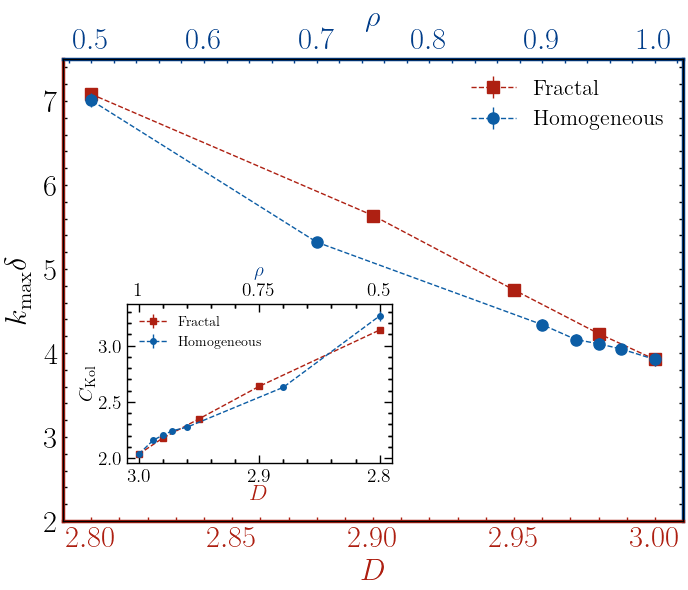

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
N = 512

# -----------------------------
# FIGURE SETUP
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 17,
    'legend.frameon': False,
    'lines.markersize': 8
})

# -----------------------------
# MAIN AXIS STYLING (LEFT + RIGHT Y-AXIS, RED)
# -----------------------------
color_x = '#ae2012'
color_y=  '#023e8a'
ax.spines['bottom'].set_color(color_x)
ax.spines['top'].set_color(color_y)
ax.spines['left'].set_color(color_x)
ax.spines['right'].set_color(color_y)

ax.spines['bottom'].set_linewidth(2.5)
ax.spines['top'].set_linewidth(2.5)
ax.spines['left'].set_linewidth(2.5)
ax.spines['right'].set_linewidth(2.5)


# --- Keep ticks on BOTH sides ---
ax.tick_params(axis='x',which='both',labelsize=22,length=3,width=1,colors=color_x)
ax.tick_params(axis='y',which='both',labelsize=22,length=3,width=1,left=True,right=True)

#
ax.tick_params(axis='both',which='both',labelsize=22,length=3,width=1,top=True,right=True)


axmain_top = ax.twiny()

axmain_top.tick_params(axis='x',which='both',labelsize=22,length=3,width=1,colors=color_y)



axmain_top.errorbar(
    alphas, -(N//3)*delta_hom / 2,
    (N//3)*delta_hom_error,
    fmt='o--', lw=1,
    label='Homogeneous'
)

ax.errorbar(
    Dims, -(N//3)*delta_frac / 2,
    (N//3)*delta_frac_error,
    fmt='s--',
    color=color_x, ecolor=color_x,
    lw=1,
    label='Fractal'
)


# Create a single combined legend using handles from both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = axmain_top.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2

ax.legend(handles, labels, loc='upper right', fontsize=16)



# ---- Reverse BOTH x-axes (MAIN PANEL) ----
# ax.invert_xaxis()
# axmain_top.invert_xaxis()

# Labels
ax.set_xlabel(r'$D$', labelpad=0, size=22, color = color_x)
ax.xaxis.set_label_coords(0.5, -0.08)

axmain_top.set_xlabel(r'$\rho$', labelpad=1, size=22,color = color_y)

ax.set_ylabel(r'$ k_{\rm max}\delta$', size=22)
ax.yaxis.set_label_coords(-0.05, 0.5)

ax.set_ylim(2,7.5)
# -----------------------------
# INSET AXES
# -----------------------------
axins = inset_axes(ax,width="57%",height="46%",loc="upper right",bbox_to_anchor=(-0.22, -0.28, 0.75, 0.75),bbox_transform=ax.transAxes,borderpad=0.0)

axins.tick_params(axis='both', which='both', labelsize=14)
ax_top = axins.twiny()
ax_top.tick_params(axis='x', which='both', labelsize=14)

ax_top.errorbar(alphas[:], c_kol_hom,c_kol_hom_error,fmt='o--', lw=1,label='Homogeneous', ms = 4
)

axins.errorbar(
Dims, c_kol_frac,
c_kol_frac_error,
fmt='s--',
color=color_x, ecolor=color_x,
lw=1, ms = 4 ,
label='Fractal'
)

# ---- Reverse BOTH x-axes (INSET) ----
axins.invert_xaxis()
ax_top.invert_xaxis()

# Inset ticks and labels
ax_top.set_xticks((1,0.75, 0.5))
ax_top.set_xticklabels([1,0.75, 0.5])

axins.set_xlabel(r'$D$', labelpad=-1, color = color_x)
ax_top.set_xlabel(r'$\rho$', labelpad=4, size=14, color = color_y)
axins.set_ylabel(r'$C_{\text{Kol}}$', labelpad=1, size=14)

axins.legend(loc='upper left', fontsize = 10)

# -----------------------------
# SAVE & SHOW
# -----------------------------
plt.savefig("C_Kol.png", dpi=250, bbox_inches='tight', pad_inches=0.01)
plt.show()
